# MSE-803 Week 5 — Activity 1: SVM Classifier for Three Classes (Iris)

Build a **Support Vector Machine** that classifies the three iris species from Fisher's classic dataset.

**Tasks**
1. Load and explore the Iris dataset (3 classes, 4 features)
2. Visualise how well the features separate the species
3. Split the data (stratified) and scale the features
4. Compare SVM kernels — linear, RBF, polynomial
5. Tune `C` / `gamma` with `GridSearchCV`
6. Evaluate on the held-out test set — accuracy, per-class report, confusion matrix
7. Draw the decision boundaries and classify new flowers

**Dataset:** `../iris/iris.data` — 150 flowers, 50 of each species (UCI Machine Learning Repository).

## 1. Setup

If you see `ModuleNotFoundError`, run the next cell once to install the packages into **this notebook's kernel**.

In [1]:
%pip install -q pandas numpy scikit-learn matplotlib
print("Dependencies ready.")


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: /usr/bin/python3 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Dependencies ready.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

# The raw UCI file has no header row
DATA_PATH = Path("../iris/iris.data")
COLUMNS = ["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]
FEATURES = COLUMNS[:-1]
CLASS_NAMES = ["Iris-setosa", "Iris-versicolor", "Iris-virginica"]

TEST_SIZE = 0.2      # 30 flowers held back, 10 per species
RANDOM_STATE = 42    # fixed seed so results repeat exactly
CV_FOLDS = 5

print(f"Reading: {DATA_PATH.resolve()}")

Reading: /home/abusufian/Peronal/workspace/repos/MSE-803-data-analytics/week-5/iris/iris.data


## 2. Load and explore the data

In [3]:
df = pd.read_csv(DATA_PATH, header=None, names=COLUMNS).dropna()
df["species"] = df["species"].str.strip()

print(f"Shape: {df.shape[0]} flowers x {df.shape[1]} columns")
print(f"Missing values: {int(df.isna().sum().sum())}")
df.head()

Shape: 150 flowers x 5 columns
Missing values: 0


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
# Three classes, perfectly balanced
df["species"].value_counts().sort_index()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [5]:
df[FEATURES].describe().round(2)

,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.05,3.76,1.20
std,0.83,0.43,1.76,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [6]:
# Average measurement per species - petals separate the classes much more than sepals
df.groupby("species")[FEATURES].mean().round(2)

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
Iris-setosa,5.01,3.42,1.46,0.24
Iris-versicolor,5.94,2.77,4.26,1.33
Iris-virginica,6.59,2.97,5.55,2.03


### Visual check — which features separate the classes?

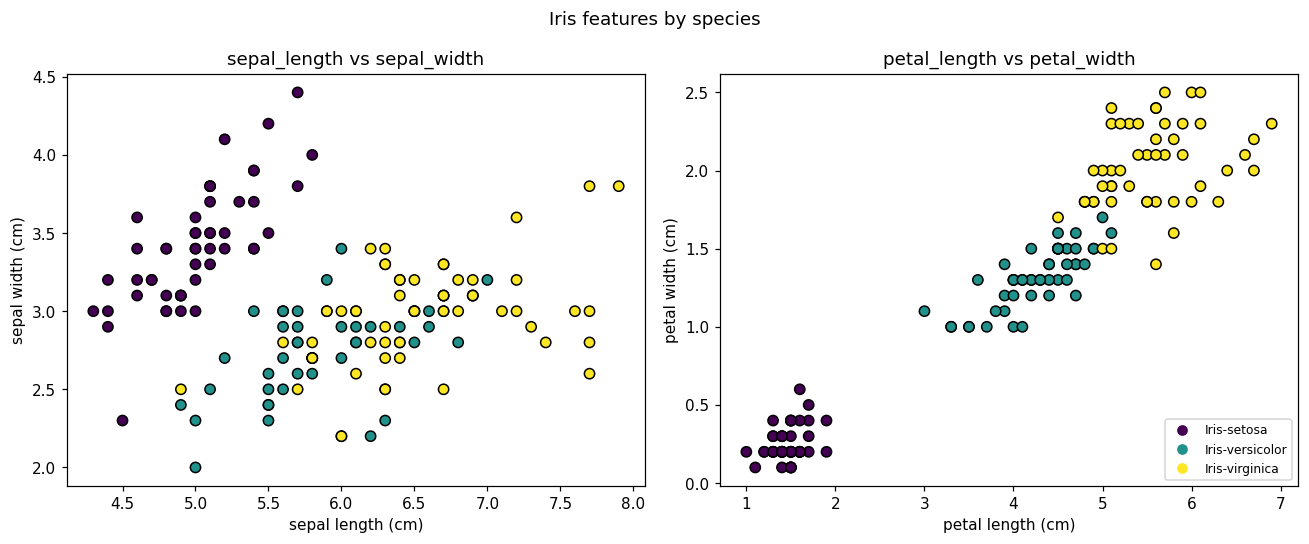

In [7]:
y_code = np.searchsorted(CLASS_NAMES, df["species"].to_numpy())  # 0 / 1 / 2 for colouring
pairs = [("sepal_length", "sepal_width"), ("petal_length", "petal_width")]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (fx, fy) in zip(axes, pairs):
    scatter = ax.scatter(df[fx], df[fy], c=y_code, cmap="viridis", edgecolor="k", s=45)
    ax.set_xlabel(f"{fx.replace('_', ' ')} (cm)")
    ax.set_ylabel(f"{fy.replace('_', ' ')} (cm)")
    ax.set_title(f"{fx} vs {fy}")
axes[1].legend(scatter.legend_elements()[0], CLASS_NAMES, loc="lower right", fontsize=8)
fig.suptitle("Iris features by species")
plt.tight_layout()
plt.show()

**Reading the plots:** on the sepal measurements (left) versicolor and virginica are tangled together.
On the petal measurements (right) all three species form clear groups, with setosa completely apart.
The petal features carry most of the signal.

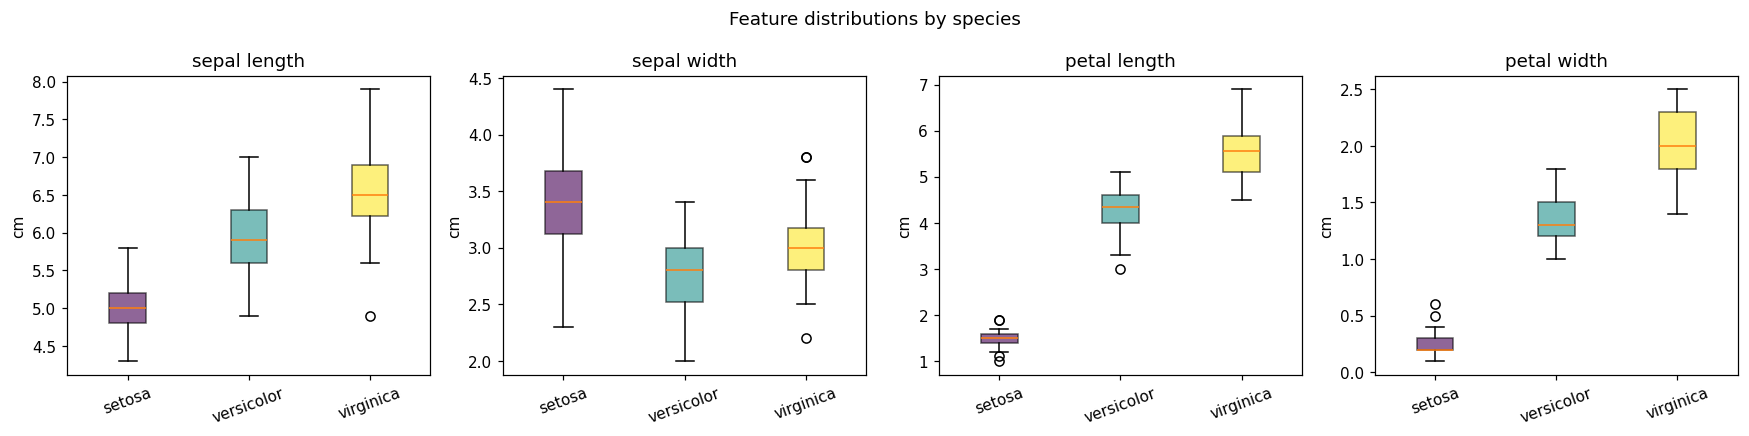

In [8]:
# Distribution of each feature per species
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, feature in zip(axes, FEATURES):
    data = [df.loc[df["species"] == name, feature] for name in CLASS_NAMES]
    box = ax.boxplot(data, patch_artist=True, tick_labels=["setosa", "versicolor", "virginica"])
    for patch, colour in zip(box["boxes"], plt.cm.viridis([0.0, 0.5, 1.0])):
        patch.set_facecolor(colour)
        patch.set_alpha(0.6)
    ax.set_title(feature.replace("_", " "))
    ax.set_ylabel("cm")
    ax.tick_params(axis="x", rotation=20)
fig.suptitle("Feature distributions by species")
plt.tight_layout()
plt.show()

## 3. Train / test split and the model pipeline

- **Stratified** split keeps the 3 classes balanced in both sets.
- `StandardScaler` goes **inside a Pipeline** so the scaler is fitted on the training fold only — no information leaks from the test data.
- `SVC` handles 3 classes with **one-vs-one**: it trains 3 binary SVMs (setosa–versicolor, setosa–virginica, versicolor–virginica) and combines them by voting.

In [9]:
def make_pipeline(**svc_params):
    """Scaler + SVM as one estimator."""
    return Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(random_state=RANDOM_STATE, **svc_params)),
    ])


X = df[FEATURES]
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {len(X_train)} flowers")
print(f"Test set:     {len(X_test)} flowers")
pd.DataFrame({
    "train": y_train.value_counts().sort_index(),
    "test": y_test.value_counts().sort_index(),
})

Training set: 120 flowers
Test set:     30 flowers


,train,test
species,,
Iris-setosa,40,10
Iris-versicolor,40,10
Iris-virginica,40,10


## 4. Compare the kernels (5-fold cross-validation)

The kernel decides the shape of the boundary between classes:

| Kernel | Boundary shape |
|--------|----------------|
| `linear` | Straight line / flat plane |
| `rbf` | Smooth curved regions around each class |
| `poly` | Polynomial curve of the chosen degree |

In [10]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

kernels = {
    "linear": {"kernel": "linear", "C": 1.0},
    "rbf": {"kernel": "rbf", "C": 1.0, "gamma": "scale"},
    "poly (deg 3)": {"kernel": "poly", "degree": 3, "C": 1.0, "gamma": "scale"},
}

rows = []
for label, params in kernels.items():
    scores = cross_val_score(make_pipeline(**params), X_train, y_train, cv=cv, scoring="accuracy")
    rows.append({"kernel": label, "mean_accuracy": scores.mean(), "std": scores.std()})

kernel_scores = pd.DataFrame(rows).sort_values("mean_accuracy", ascending=False)
kernel_scores.round(4)

,kernel,mean_accuracy,std
0,linear,0.9750,0.0333
1,rbf,0.9667,0.0167
2,poly (deg 3),0.9000,0.0425


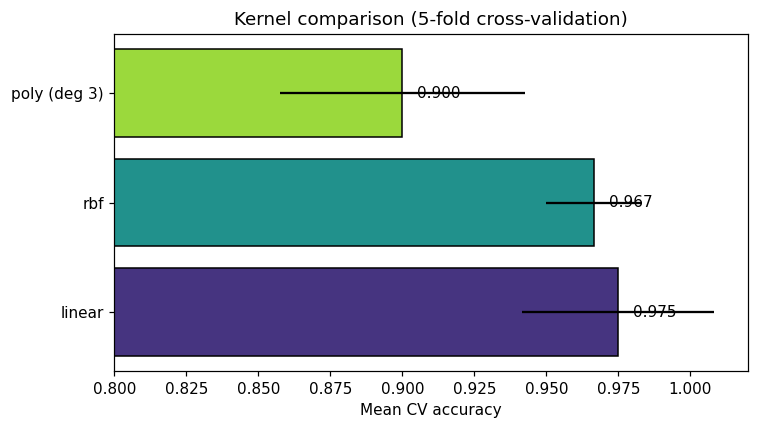

Best kernel: linear


In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(kernel_scores["kernel"], kernel_scores["mean_accuracy"],
        xerr=kernel_scores["std"], color=plt.cm.viridis([0.15, 0.5, 0.85]), edgecolor="k")
for name, value in zip(kernel_scores["kernel"], kernel_scores["mean_accuracy"]):
    ax.text(value + 0.005, name, f"{value:.3f}", va="center")
ax.set_xlim(0.8, 1.02)
ax.set_xlabel("Mean CV accuracy")
ax.set_title("Kernel comparison (5-fold cross-validation)")
plt.tight_layout()
plt.show()

print(f"Best kernel: {kernel_scores.iloc[0]['kernel']}")

## 5. Tune the hyper-parameters with `GridSearchCV`

- **`C`** — how much the model is punished for misclassifying a training point. Small `C` = wide, forgiving margin; large `C` = narrow margin that tries to get every training point right (and can overfit).
- **`gamma`** — how far the influence of a single point reaches in the RBF kernel. Large `gamma` = tight, wiggly boundaries.

In [12]:
param_grid = [
    {"svm__kernel": ["linear"], "svm__C": [0.1, 1, 10, 100]},
    {"svm__kernel": ["rbf"], "svm__C": [0.1, 1, 10, 100], "svm__gamma": ["scale", 0.01, 0.1, 1]},
    {"svm__kernel": ["poly"], "svm__C": [0.1, 1, 10], "svm__degree": [2, 3], "svm__gamma": ["scale"]},
]

search = GridSearchCV(make_pipeline(), param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
search.fit(X_train, y_train)

best_model = search.best_estimator_
print(f"Combinations tested: {len(search.cv_results_['params'])}")
print(f"Best parameters:     {search.best_params_}")
print(f"Best CV accuracy:    {search.best_score_:.4f}")

Combinations tested: 26
Best parameters:     {'svm__C': 0.1, 'svm__kernel': 'linear'}
Best CV accuracy:    0.9750


## Confusion matrix for every kernel

The evaluation above only used the **overall best model** (linear kernel). To see how each kernel type actually performs, each one is refit here using **its own best hyper-parameters** from the grid search, then evaluated on the same test set.

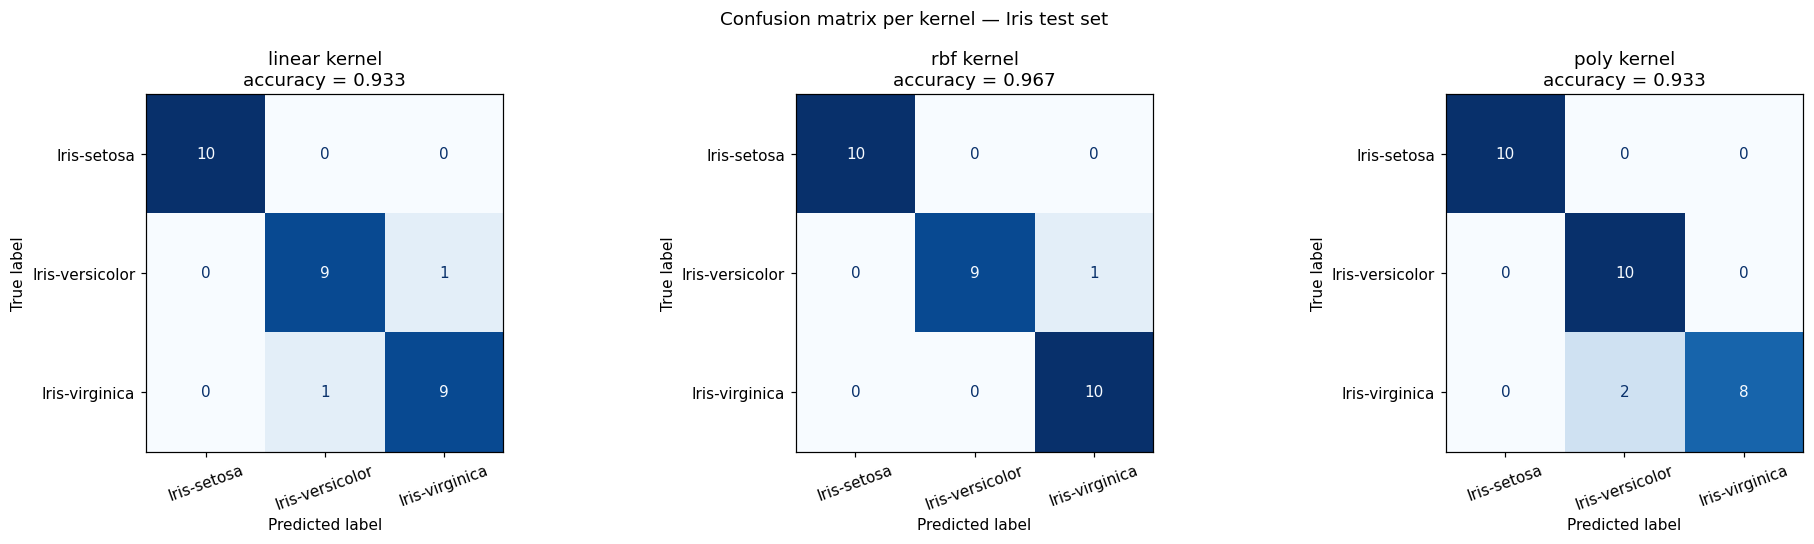

,kernel,params,test_accuracy
0,linear,"{'C': 0.1, 'kernel': 'linear'}",0.9333
1,rbf,"{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}",0.9667
2,poly,"{'C': 10, 'degree': 3, 'gamma': 'scale', 'kern...",0.9333


In [13]:
def best_params_per_kernel(search):
    """Pull out each kernel's own best hyper-parameters from the grid search results."""
    results = pd.DataFrame(search.cv_results_)
    best = {}
    for kernel in results["param_svm__kernel"].unique():
        subset = results[results["param_svm__kernel"] == kernel]
        top = subset.loc[subset["mean_test_score"].idxmax()]
        params = {k.replace("svm__", ""): v for k, v in top["params"].items()}
        best[kernel] = params
    return best


best_params = best_params_per_kernel(search)
order = [k for k in ["linear", "rbf", "poly"] if k in best_params]

kernel_results = {}
fig, axes = plt.subplots(1, len(order), figsize=(6 * len(order), 5))
if len(order) == 1:
    axes = [axes]

for ax, kernel in zip(axes, order):
    params = best_params[kernel]
    model_k = make_pipeline(**params).fit(X_train, y_train)
    y_pred_k = model_k.predict(X_test)
    acc_k = accuracy_score(y_test, y_pred_k)
    cm_k = confusion_matrix(y_test, y_pred_k, labels=CLASS_NAMES)
    kernel_results[kernel] = {"params": params, "accuracy": acc_k, "y_pred": y_pred_k}

    ConfusionMatrixDisplay(cm_k, display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{kernel} kernel\naccuracy = {acc_k:.3f}")
    ax.tick_params(axis="x", rotation=20)

fig.suptitle("Confusion matrix per kernel — Iris test set")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "kernel": order,
    "params": [kernel_results[k]["params"] for k in order],
    "test_accuracy": [kernel_results[k]["accuracy"] for k in order],
}).round(4)

In [14]:
# Full classification report for each kernel
for kernel in order:
    print(f"--- kernel = {kernel}  (params: {kernel_results[kernel]['params']}) ---")
    print(classification_report(y_test, kernel_results[kernel]["y_pred"], target_names=CLASS_NAMES, digits=3))

--- kernel = linear  (params: {'C': 0.1, 'kernel': 'linear'}) ---
                 precision    recall  f1-score   support

    Iris-setosa      1.000     1.000     1.000        10
Iris-versicolor      0.900     0.900     0.900        10
 Iris-virginica      0.900     0.900     0.900        10

       accuracy                          0.933        30
      macro avg      0.933     0.933     0.933        30
   weighted avg      0.933     0.933     0.933        30

--- kernel = rbf  (params: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}) ---
                 precision    recall  f1-score   support

    Iris-setosa      1.000     1.000     1.000        10
Iris-versicolor      1.000     0.900     0.947        10
 Iris-virginica      0.909     1.000     0.952        10

       accuracy                          0.967        30
      macro avg      0.970     0.967     0.967        30
   weighted avg      0.970     0.967     0.967        30

--- kernel = poly  (params: {'C': 10, 'degree': 3, 'gamma'

**Reading the three matrices:** all three kernels get every setosa flower right. The RBF kernel (with its tuned `C=1, gamma=0.1`) makes only **1 mistake** (29/30), better than the linear kernel's 2 mistakes. The polynomial kernel also makes 2 mistakes, but note they land differently — it confuses 2 virginica flowers as versicolor, while the linear kernel splits its 2 errors one each way. This is why cross-validation (which averages over many splits) picked linear overall, even though on this particular test split RBF happened to do slightly better.

In [15]:
# Top 10 parameter combinations
results = pd.DataFrame(search.cv_results_)
results["params"] = results["params"].astype(str)
results[["params", "mean_test_score", "std_test_score", "rank_test_score"]] \
    .sort_values("rank_test_score").head(10).round(4).reset_index(drop=True)

,params,mean_test_score,std_test_score,rank_test_score
0,"{'svm__C': 0.1, 'svm__kernel': 'linear'}",0.9750,0.0204,1
1,"{'svm__C': 1, 'svm__kernel': 'linear'}",0.9750,0.0333,1
2,"{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne...",0.9750,0.0204,1
3,"{'svm__C': 1, 'svm__gamma': 0.1, 'svm__kernel'...",0.9750,0.0204,1
4,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.9667,0.0167,5
5,"{'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke...",0.9667,0.0167,5
6,"{'svm__C': 10, 'svm__kernel': 'linear'}",0.9667,0.0312,5
7,"{'svm__C': 10, 'svm__gamma': 0.1, 'svm__kernel...",0.9667,0.0312,5
8,"{'svm__C': 100, 'svm__gamma': 0.1, 'svm__kerne...",0.9667,0.0312,5
9,"{'svm__C': 100, 'svm__kernel': 'linear'}",0.9583,0.0264,10


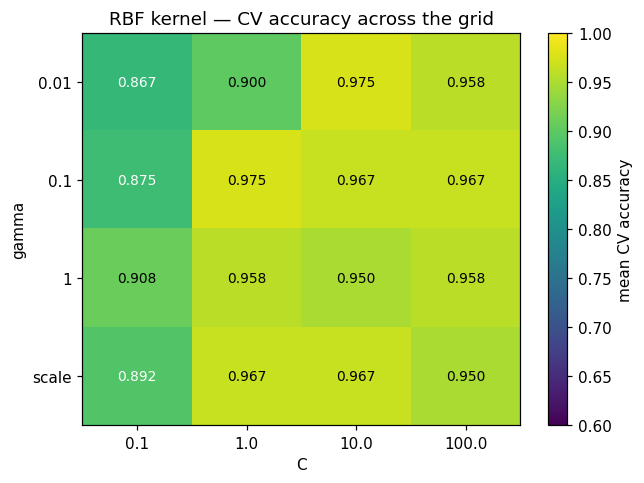

In [16]:
# How the RBF kernel responds to C and gamma
rbf = results[results["param_svm__kernel"] == "rbf"].copy()
grid = rbf.pivot_table(index="param_svm__gamma", columns="param_svm__C", values="mean_test_score")

fig, ax = plt.subplots(figsize=(6, 4.5))
im = ax.imshow(grid.values, cmap="viridis", aspect="auto", vmin=0.6, vmax=1.0)
ax.set_xticks(range(len(grid.columns)), [str(c) for c in grid.columns])
ax.set_yticks(range(len(grid.index)), [str(g) for g in grid.index])
ax.set_xlabel("C")
ax.set_ylabel("gamma")
ax.set_title("RBF kernel — CV accuracy across the grid")
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        ax.text(j, i, f"{grid.values[i, j]:.3f}", ha="center", va="center",
                color="w" if grid.values[i, j] < 0.9 else "k", fontsize=9)
fig.colorbar(im, ax=ax, label="mean CV accuracy")
plt.tight_layout()
plt.show()

## 6. Evaluate on the held-out test set

In [17]:
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Test accuracy: {accuracy:.4f}  ({int(round(accuracy * len(y_test)))}/{len(y_test)} correct)\n")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=3))

Test accuracy: 0.9333  (28/30 correct)

                 precision    recall  f1-score   support

    Iris-setosa      1.000     1.000     1.000        10
Iris-versicolor      0.900     0.900     0.900        10
 Iris-virginica      0.900     0.900     0.900        10

       accuracy                          0.933        30
      macro avg      0.933     0.933     0.933        30
   weighted avg      0.933     0.933     0.933        30



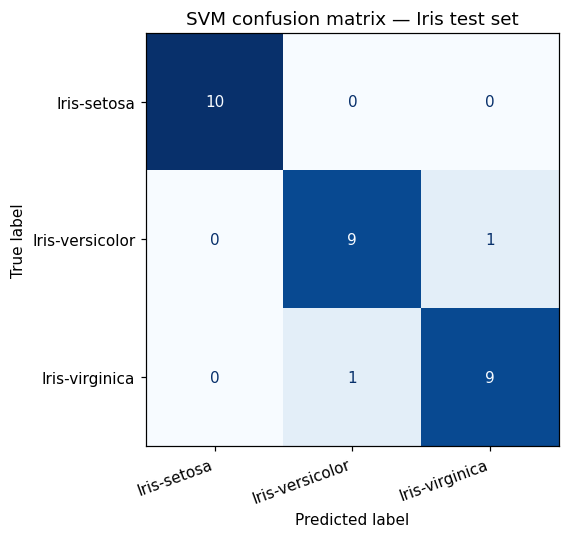

,Iris-setosa,Iris-versicolor,Iris-virginica
Iris-setosa,10,0,0
Iris-versicolor,0,9,1
Iris-virginica,0,1,9


In [18]:
cm = confusion_matrix(y_test, y_pred, labels=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("SVM confusion matrix — Iris test set")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)

In [19]:
# Which flowers did the model get wrong?
wrong = X_test.copy()
wrong["actual"] = y_test
wrong["predicted"] = y_pred
wrong = wrong[wrong["actual"] != wrong["predicted"]]

print(f"Misclassified flowers: {len(wrong)}")
wrong

Misclassified flowers: 2


,sepal_length,sepal_width,petal_length,petal_width,actual,predicted
134,6.1,2.6,5.6,1.4,Iris-virginica,Iris-versicolor
77,6.7,3.0,5.0,1.7,Iris-versicolor,Iris-virginica


In [20]:
# Support vectors: the training points that actually define the boundary
svm = best_model.named_steps["svm"]
support = pd.Series(svm.n_support_, index=CLASS_NAMES, name="support_vectors")

print(f"Total support vectors: {svm.n_support_.sum()} out of {len(X_train)} training flowers")
support

Total support vectors: 56 out of 120 training flowers


Iris-setosa         6
Iris-versicolor    28
Iris-virginica     22
Name: support_vectors, dtype: int32

Setosa needs only a handful of support vectors because it sits far from the other two.
Most of the model's effort goes into the **versicolor / virginica** border — which is exactly where its errors are.

## 7. Decision boundaries

The model uses all 4 features, so its boundary lives in 4-D and cannot be drawn.
To *see* what each kernel does, we retrain on just the two petal features and colour the regions the model assigns to each class.

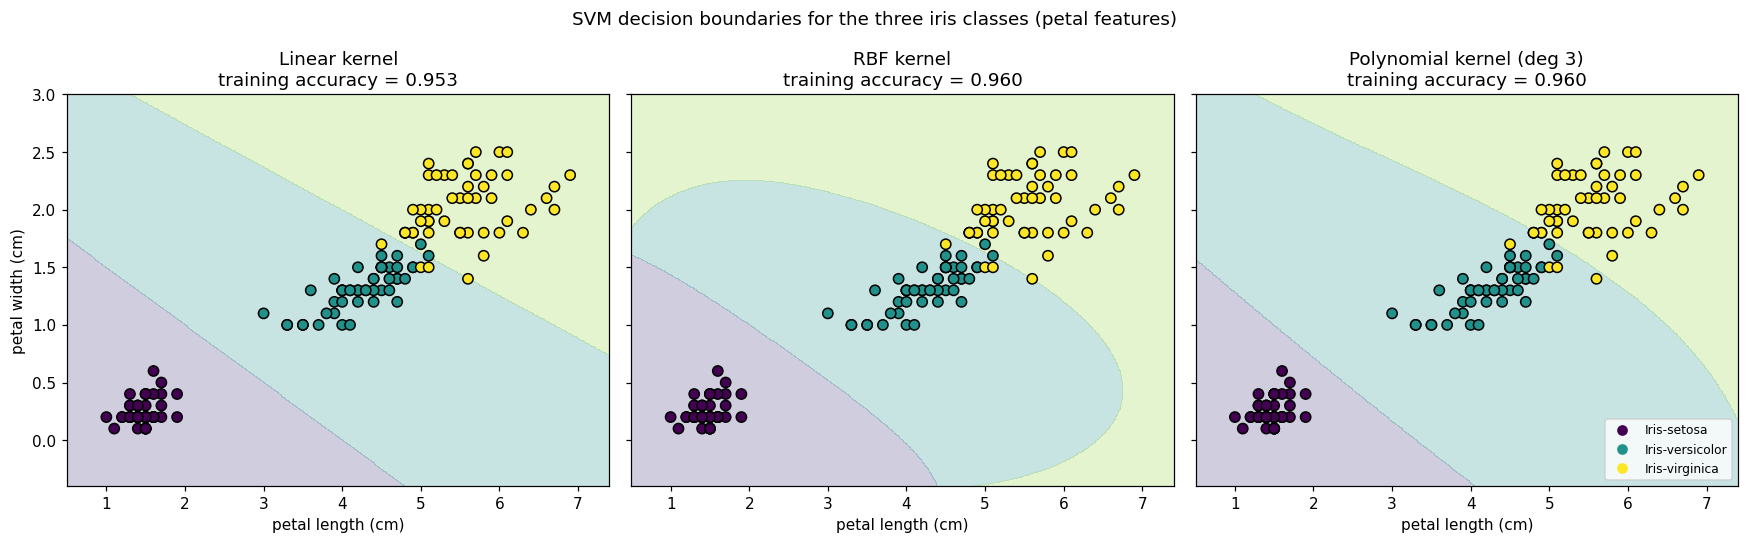

In [21]:
PLOT_FEATURES = ["petal_length", "petal_width"]
X2 = df[PLOT_FEATURES].to_numpy()
y2 = df["species"].to_numpy()

x_min, x_max = X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5
y_min, y_max = X2[:, 1].min() - 0.5, X2[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
grid_points = np.c_[xx.ravel(), yy.ravel()]

plot_kernels = [
    ("Linear kernel", {"kernel": "linear", "C": 1.0}),
    ("RBF kernel", {"kernel": "rbf", "C": 1.0, "gamma": "scale"}),
    ("Polynomial kernel (deg 3)", {"kernel": "poly", "degree": 3, "C": 1.0, "gamma": "scale"}),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
for ax, (title, params) in zip(axes, plot_kernels):
    model2 = make_pipeline(**params).fit(X2, y2)
    zz = np.searchsorted(CLASS_NAMES, model2.predict(grid_points)).reshape(xx.shape)

    ax.contourf(xx, yy, zz, alpha=0.25, levels=[-0.5, 0.5, 1.5, 2.5], cmap="viridis")
    scatter = ax.scatter(X2[:, 0], X2[:, 1], c=y_code, cmap="viridis", edgecolor="k", s=45)
    ax.set_title(f"{title}\ntraining accuracy = {model2.score(X2, y2):.3f}")
    ax.set_xlabel("petal length (cm)")
axes[0].set_ylabel("petal width (cm)")
axes[-1].legend(scatter.legend_elements()[0], CLASS_NAMES, loc="lower right", fontsize=8)
fig.suptitle("SVM decision boundaries for the three iris classes (petal features)")
plt.tight_layout()
plt.show()

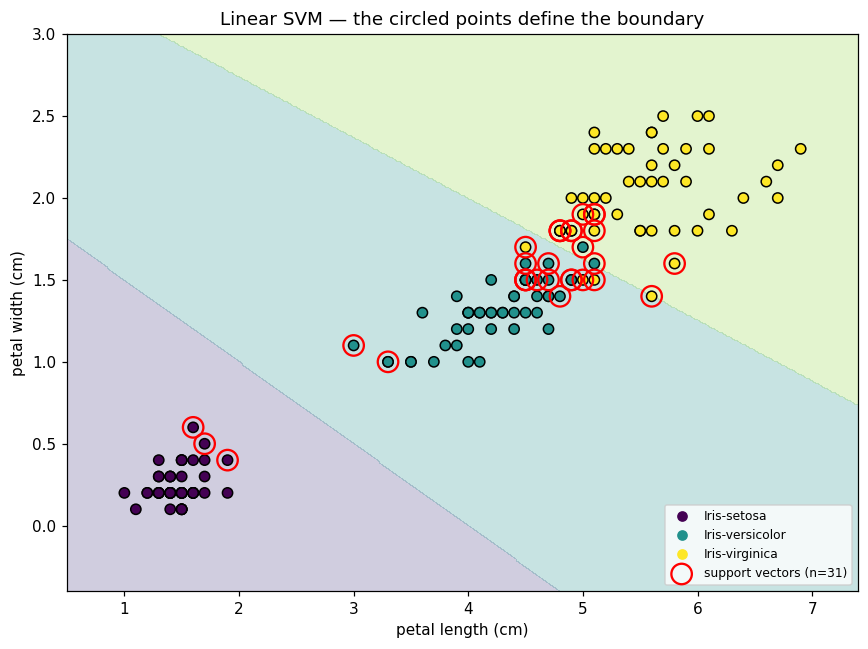

In [22]:
# Same 2-D model, with the support vectors circled
model2 = make_pipeline(kernel="linear", C=1.0).fit(X2, y2)
zz = np.searchsorted(CLASS_NAMES, model2.predict(grid_points)).reshape(xx.shape)
sv = model2.named_steps["scaler"].inverse_transform(model2.named_steps["svm"].support_vectors_)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, zz, alpha=0.25, levels=[-0.5, 0.5, 1.5, 2.5], cmap="viridis")
scatter = ax.scatter(X2[:, 0], X2[:, 1], c=y_code, cmap="viridis", edgecolor="k", s=45)
ax.scatter(sv[:, 0], sv[:, 1], s=180, facecolors="none", edgecolors="red", linewidths=1.5,
           label=f"support vectors (n={len(sv)})")
ax.set_xlabel("petal length (cm)")
ax.set_ylabel("petal width (cm)")
ax.set_title("Linear SVM — the circled points define the boundary")
handles = list(scatter.legend_elements()[0]) + [ax.collections[-1]]
ax.legend(handles, CLASS_NAMES + [f"support vectors (n={len(sv)})"], loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 8. Classify new flowers

In [23]:
new_flowers = pd.DataFrame(
    [
        [5.0, 3.4, 1.5, 0.2],   # small petals -> setosa
        [6.0, 2.7, 4.2, 1.3],   # medium petals -> versicolor
        [6.7, 3.0, 5.8, 2.1],   # large petals -> virginica
    ],
    columns=FEATURES,
)

new_flowers["predicted_species"] = best_model.predict(new_flowers)
new_flowers

,sepal_length,sepal_width,petal_length,petal_width,predicted_species
0,5.0,3.4,1.5,0.2,Iris-setosa
1,6.0,2.7,4.2,1.3,Iris-versicolor
2,6.7,3.0,5.8,2.1,Iris-virginica


## 9. Conclusions

| Item | Result |
|------|--------|
| Best model | `SVC(kernel='linear', C=0.1)` on standardised features |
| Cross-validation accuracy | 0.975 |
| **Test accuracy** | **0.933 — 28 of 30 correct** |
| Setosa | precision and recall = 1.000 |
| Versicolor / virginica | 0.900 each — the only 2 errors, both on their shared border |

**What the results show**

1. **Setosa is perfectly separable.** Its petals are so much smaller that a straight line isolates it completely.
2. **Versicolor and virginica overlap.** Their petals meet around 5 cm, and every mistake the model makes is there — a known property of this dataset, not a modelling fault.
3. **Simpler beat more flexible.** The linear kernel with a small `C` (wide, soft margin) outperformed RBF and polynomial; the degree-3 polynomial curved its boundary to fit noise and lost ~7 points of CV accuracy.
4. **Scaling was essential.** Without `StandardScaler`, sepal length (4.3–7.9 cm) would dominate petal width (0.1–2.5 cm) in the SVM's distance calculations.
5. **Only 56 of 120 training flowers are support vectors**, and just 6 of them are setosa — the model's boundary is decided almost entirely by the overlapping pair.